## Sanity checks

In [ ]:
import numpy as np
import scipy.sparse as sps

%matplotlib inline

import analysis as am
import encoding as E

In [2]:
def dense(M):
    return np.asarray(M.todense()) if sps.issparse(M) else np.asarray(M)

for nb in (1, 2, 3):
    n, nl = 4 * nb, 2 * nb
    U = E.get_encoder_isometry(nb)
    proj = lambda op, U=U: dense(U.conj().T @ E.as_csr(op) @ U)
    Zb = lambda k, nl=nl: E.logical_Z(k, nl).full()
    Xb = lambda k, nl=nl: E.logical_X(k, nl).full()

    assert np.allclose(dense(U.conj().T @ U), np.eye(2 ** nl))              # isometry

    for i in range(nb):                                             # Table II
        a, b, q = 2 * i, 2 * i + 1, 4 * i
        Z_, X_ = lambda k, n=n: E.Z(k, n), lambda k, n=n: E.X(k, n)
        assert np.allclose(proj(Z_(q)   * Z_(q+1)),  Zb(a))
        assert np.allclose(proj(Z_(q)   * Z_(q+2)),  Zb(b))
        assert np.allclose(proj(Z_(q+1) * Z_(q+2)),  Zb(a) @ Zb(b))
        assert np.allclose(proj(X_(q)   * X_(q+2)), -Xb(a))
        assert np.allclose(proj(X_(q)   * X_(q+1)),  Xb(b))
        assert np.allclose(proj(X_(q+1) * X_(q+2)), -Xb(a) @ Xb(b))

    # S_enc is in the kernel of Hpen
    assert np.abs(dense(E.as_csr(E.build_Hpen(nb)) @ U)).max() < 1e-12

    # Each penalty term projects to a logical Pauli and has no leakage outside the code space
    P = E.get_encoder_projector(U)
    I = sps.identity(U.shape[0], format="csr")
    for kind, p, g, Pa in E.penalty_terms(nb):
        M, i, sign = proj(Pa), p // 2, (+1 if p % 2 == 0 else -1)
        want = Xb(2 * i + 1) if kind == "x" else Zb(2 * i)
        assert np.allclose(M, sign * want)                          # closed form
        assert np.abs(dense((I - P) @ E.as_csr(Pa) @ U)).max() < 1e-12   # no leakage

    print(f"nb={nb}: Table II, isometry, kernel, closed form and no-leakage all verified")

nb=1: Table II, isometry, kernel, closed form and no-leakage all verified
nb=2: Table II, isometry, kernel, closed form and no-leakage all verified
nb=3: Table II, isometry, kernel, closed form and no-leakage all verified


## What was simulated

| axis | values |
|---|---|
| $\lambda$ | $2^0, 2^1, \dots 2^{16}$ |
| $\delta$ | $0,\ 10^{-7},\ 10^{-6},\ 10^{-5},\ 10^{-4},\ 10^{-3}$ |
| seed | $0,1, \dots, 49$ (50 realisations of noise + miscalibration + initial state) |

To regenerate the data files in `data/` from scratch:

```bash
python Hpen_miscal/simulate.py --nb 2 --noise 0.1 --t 1.0 \
  --lamb 1,2,4,8,16,32,64,128,256,512,1024,2048,4096,8192,16384,32768,65536 \
  --miscal 0,1e-7,1e-6,1e-5,1e-4,1e-3 --seeds 0-49 --outdir Hpen_miscal/data
```

## Results

In [3]:
res = am.report(nb=2, noise=0.1, t=1.0)

Penalty miscalibration sweep: nb = 2, noise = 0.1, t = 1.0, 50 seeds
  lamb  1 .. 65536 (17 values)
  delta [0.0, 1e-07, 1e-06, 1e-05, 0.0001, 0.001]

1. delta = 0 baseline (fitted over lamb >= 32)
   A = lamb * eps = 0.4197   (per-lamb spread 0.380-0.458)
   eps / leakage = 1.0117  (the infidelity is almost entirely leakage)

2. Global fit of the EXCESS  eps(l,d) - eps(l,0) = B d^2 l^2 + C d
   (69 points, paired per seed, weighted by the SEM of the difference)
   B = 8.100    C = -0.2056
   B = 7.918  with the C term omitted
   C measured directly off the small-lamb wing: -0.1670 (range -0.2354..-0.1534, n=16)  -> consistent
   [the naive alternative -- fit eps itself over lamb >= 32 with A
    fixed -- gives B = 7.703, C = +0.9627 (45 pts): C comes out with
    the WRONG SIGN, because above lamb = 32 the B term dominates and C is
    unidentifiable.  Use the excess fit; see fit_excess docstring.]

3. B against the analytic form B = kappa * (20/3) * nb
   B_analytic = kappa * (20/3) 

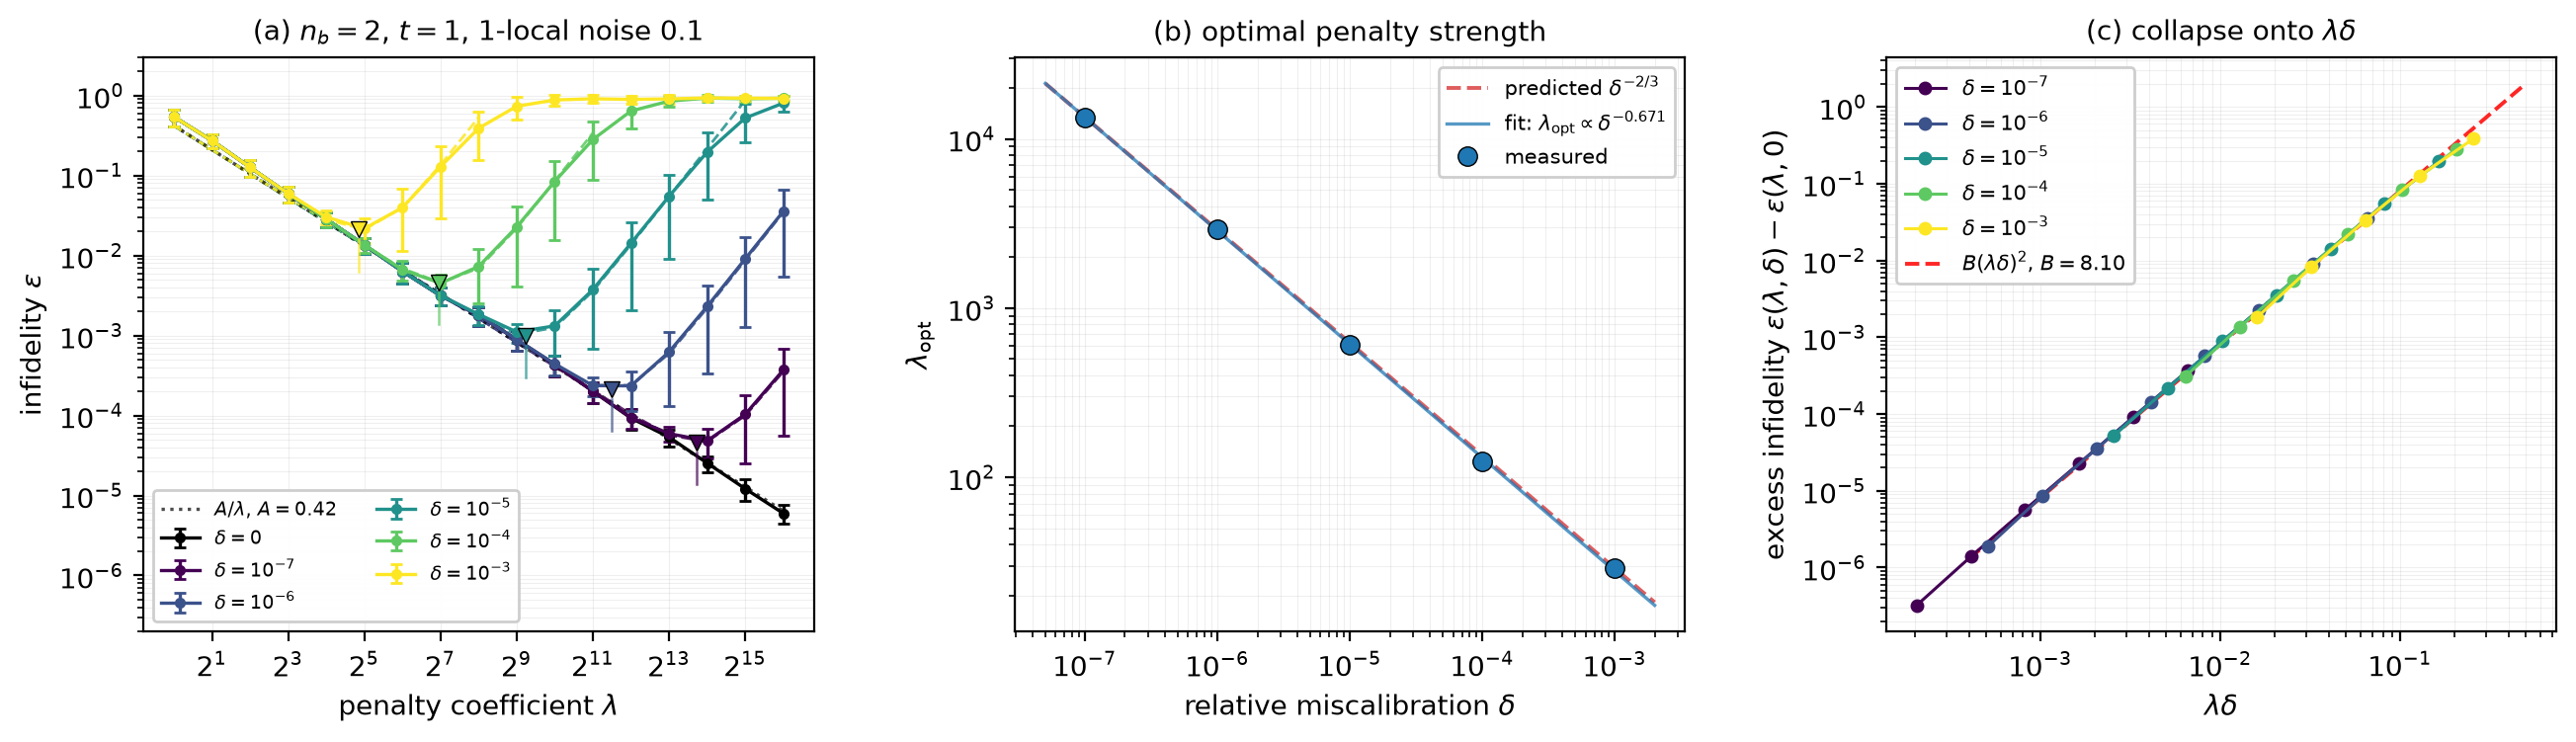

In [4]:
pdf, png = am.make_figure(res, "fig_miscal.pdf", noise=0.1)
from IPython.display import Image, display

display(Image(filename=png))